# Introduction to Machine Learning -- MC886
# Assignment 2 - Model Selection and Regularization

**Professor:** Marcelo da Silva Reis  
**PED:** Daniel Gardin Gratti  
**PAD:** Guilherme Henrique Ichiro Seto Ito

In [18]:
# Please, enter your name and RA number in the lines below:
print("Ana Beatriz Hidalgo", "|", "248238")
print("Maria Gabriela Lustosa Oliveira", "|", "188504")
print("Lucas Palacio Almeida", "|", "236380")

Ana Beatriz Hidalgo | 248238
Maria Gabriela Lustosa Oliveira | 188504
Lucas Palacio Almeida | 236380


---

## Objective

This assignment investigates the effects of overfitting in different data regimes
and test conditions.
The goal is to understand the different results of regularization when data
availability changes, and how they impact the generalization across two different
distributions.

### Guidelines

> Please read these guidelines carefully.

1. Questions can be answered in English or in Portuguese.

2. Use data visualization as a primary tool for understanding the problem. Inspect the training data, corrupted inputs, and model behavior. When an assumption is uncertain, verify it empirically through plots.

3. The provided code serves only as a reference. Modifications are allowed, including changes to functions and the introduction of new components. Code clarity and organization are required.

4. The use of generative AI tools (e.g., ChatGPT, GitHub Copilot, DeepSeek, LLaMA) is permitted strictly for implementation support. The use of AI for interpreting, analyzing, or discussing experimental results is discouraged. Submissions must include:
   - A declaration of which models were used.
   - The prompts that generated any incorporated code.

5. Do not hesitate to reach out to the PED/PAD via Discord.

### About the Dataset

This assignment uses the [MNIST](https://web.archive.org/web/20240213122836/http://yann.lecun.com/exdb/mnist/) dataset, a standard benchmark for image classification. It consists of 28×28 grayscale images of handwritten digits (0–9), where each pixel encodes an intensity value in [0, 255].

MNIST is useful here because it is simple enough that a linear model can do well on it, which means the learned weights are directly interpretable as images, where each weight corresponds to the influence of each pixel.

To study robustness and distribution shift, this assignment uses corrupted variants from [MNIST-C](https://github.com/google-research/mnist-c), which applies systematic corruptions to the original images.

The training set consists entirely of corrupted images. The test set contains **two splits**:
- `test_corrupted`: corrupted test images (same distribution as training).
- `test_clean`: the original, uncorrupted MNIST test images.

Performance on `test_corrupted` measures how well the model learned the training task.
Performance on `test_clean` measures how well the model learned digit recognition.

Your job is to train three different models, each one with different number of
available samples:
- Full-data (60000 samples)
- Partial-data (10000 samples)
- Scarce-data (1000 samples)

Finding the best combination of hyper-parameter for each one of them.

In [19]:
from typing import Any

from numpy.typing import NDArray
import numpy as np
import pandas as pd
import random

import torch
import torch.nn as nn
from torch import optim

import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility.
# Do not tune this number
# Re-run the notebook from the beginning before submitting.
seed = 248238
torch.random.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [20]:
# The dataset is available in the classroom assignment.
# Ensure you have downloaded it and placed it alongside this notebook.

# DO NOT change this cell

def subsample_dataset(
    X: NDArray[Any], y: NDArray[Any], n: int
) -> tuple[NDArray[Any], NDArray[Any]]:
    n_samples = len(y)

    idxs = np.random.choice(
        n_samples, size=n, replace=False
    )

    return X[idxs], y[idxs]

X_full = np.load("data/train/train_images.npy")
y_full = np.load("data/train/train_labels.npy")

X_partial, y_partial = subsample_dataset(X_full, y_full, 10_000)
X_scarce, y_scarce = subsample_dataset(X_full, y_full, 1_000)

print(f"Full-data set: {X_full.shape[0]} samples")
print(f"Partial-data set: {X_partial.shape[0]} samples")
print(f"Scarce-data set: {X_scarce.shape[0]} samples")

Full-data set: 60000 samples
Partial-data set: 10000 samples
Scarce-data set: 1000 samples


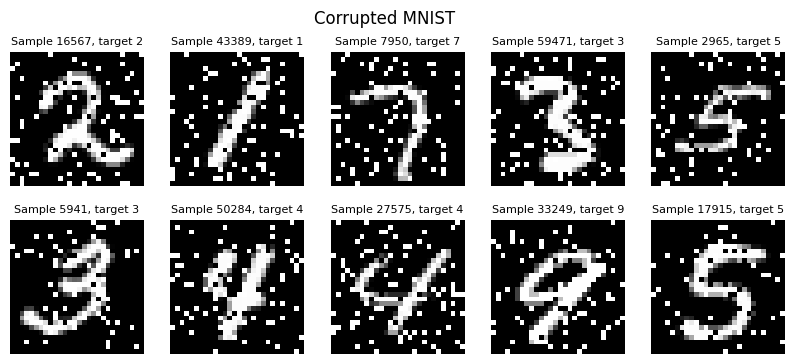

In [21]:
n_cols = 5
n_rows = 2

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2*n_cols, 2*n_rows))

fig.suptitle("Corrupted MNIST")

for i in range(n_rows):
    for j in range(n_cols):
        ax = axs[i, j]
        idx = random.randint(0, len(X_full)-1)

        ax.set_title(f"Sample {idx}, target {y_full[idx]}", fontsize=8)
        ax.imshow(X_full[idx], cmap='grey')
        ax.set_axis_off()

---

## Part 1. Data Analysis and Preprocessing

### 1.1 Exploring the corruption

**(1.0 point)**

Before any modeling, understand what the corruption actually does to the data.

Is the corruption random per-pixel noise, or is it a structured perturbation?
Explore the **training** dataset, understand the distribution and the effects of the introduced
noise.

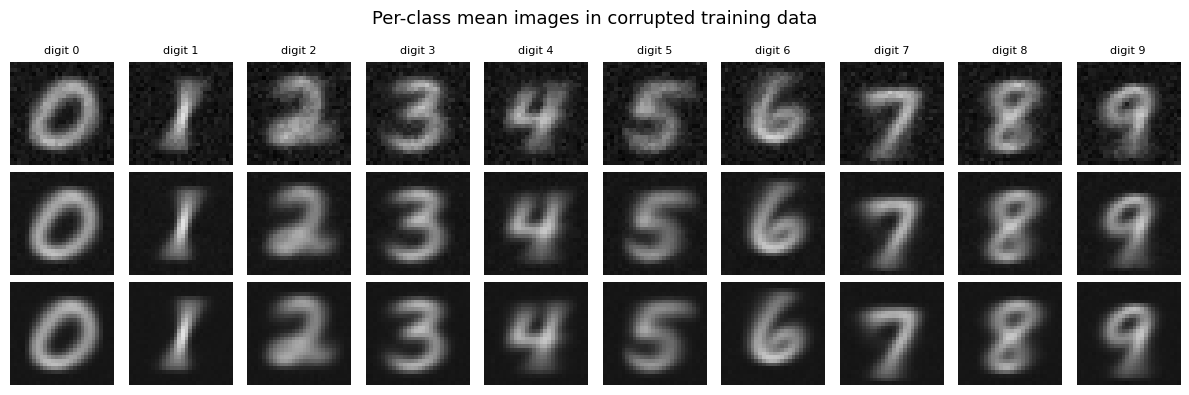

In [22]:
data_regimes = {
    "Scarce": (X_scarce, y_scarce),
    "Partial": (X_partial, y_partial),
    "Full": (X_full, y_full),
}

fig, axs = plt.subplots(len(data_regimes), 10, figsize=(4*len(data_regimes), 4))
for digit in range(10):
    axs[0, digit].set_title(f"digit {digit}", fontsize=8)

for i, name in enumerate(data_regimes):
    X, y = data_regimes[name]


    for digit in range(10):
        mask = (y == digit)
        mean_img = X[mask].mean(axis=0)
        axs[i, digit].imshow(mean_img, cmap="gray", vmin=0, vmax=255)
        axs[i, digit].axis("off")

    axs[i, 0].set_ylabel(f"{name}-data regime", fontsize=9)

plt.suptitle("Per-class mean images in corrupted training data", fontsize=13)
plt.tight_layout()
plt.show()

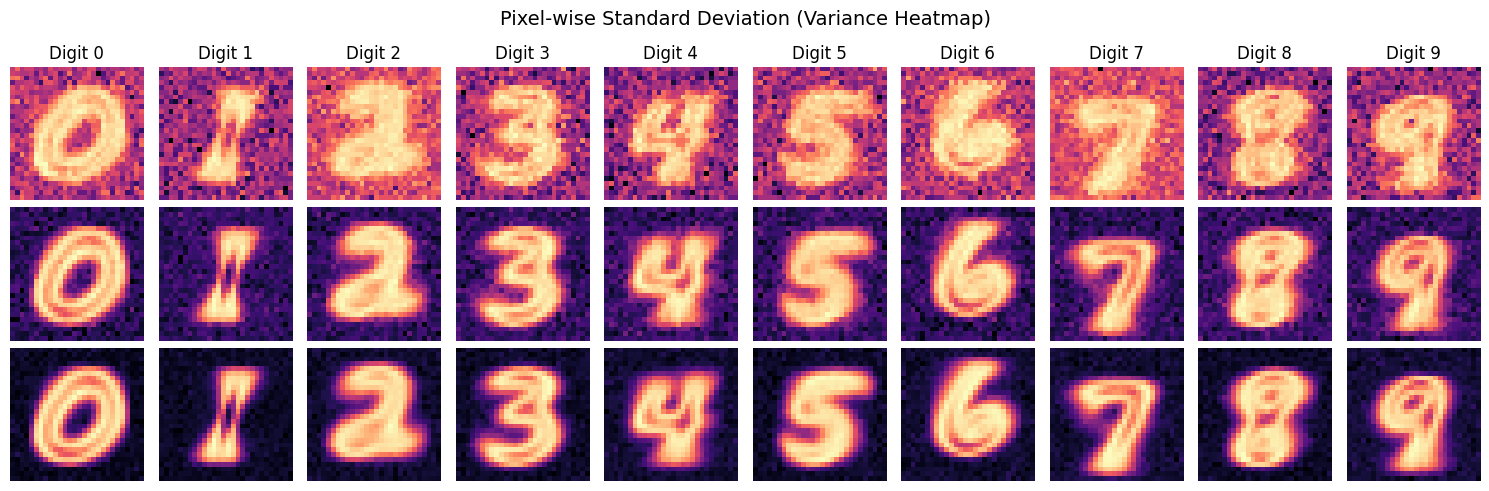

In [23]:
# Implement other visualizations to understand the corruption. 

fig, axs = plt.subplots(len(data_regimes), 10, figsize=(15, 5))

for i, name in enumerate(data_regimes):
    X, y = data_regimes[name]
    
    for digit in range(10):
        mask = (y == digit)
        # Calculamos o desvio padrão ao longo do eixo das amostras
        std_img = X[mask].std(axis=0)
        
        # Usamos o mapa 'magma' ou 'hot' para destacar a variância
        im = axs[i, digit].imshow(std_img, cmap="magma")
        axs[i, digit].axis("off")
        
        if i == 0:
            axs[i, digit].set_title(f"Digit {digit}")

    axs[i, 0].set_ylabel(f"{name} (Std Dev)", rotation=0, labelpad=40, va='center')

plt.suptitle("Pixel-wise Standard Deviation (Variance Heatmap)", fontsize=14)
plt.tight_layout()
plt.show()

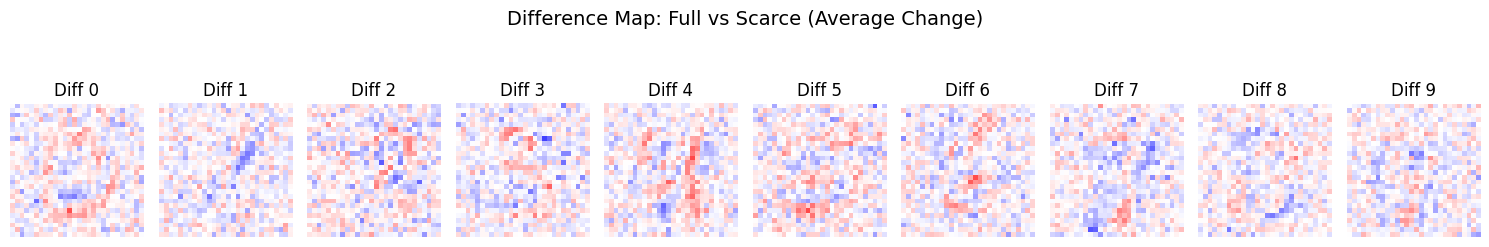

In [24]:
# Vamos comparar o regime 'Full' com o 'Scarce' para ver o impacto máximo
X_f, y_f = data_regimes["Full"]
X_s, y_s = data_regimes["Scarce"]

fig, axs = plt.subplots(1, 10, figsize=(15, 3))

for digit in range(10):
    mean_full = X_f[y_f == digit].mean(axis=0)
    mean_scarce = X_s[y_s == digit].mean(axis=0)
    
    # A diferença mostra o que o ruído/corrupção alterou
    diff_img = mean_full - mean_scarce
    
    # Usamos um mapa divergente (bwr - blue white red) 
    # Vermelho: valor aumentou no Full | Azul: valor diminuiu no Full
    im = axs[digit].imshow(diff_img, cmap="bwr", vmin=-50, vmax=50)
    axs[digit].set_title(f"Diff {digit}")
    axs[digit].axis("off")

plt.suptitle("Difference Map: Full vs Scarce (Average Change)", fontsize=14)
plt.tight_layout()
plt.show()

> **Question 1.1**
>
> Describe the corruption. Is it random and per-sample, or is it systematic and shared across images? Does it vary across digit classes?
>
> Are there data regimes where the corruption can effect more than in others?
> Hypothesize how these different regimes will affect a model trained on them.

*Question 1.1*

* Describe the corruption. Is it random and per-sample, or is it systematic and shared across images? Does it vary across digit classes?

O efeito de corrompimento parece ser sistemático e compartilhado ao longo das imagens de um mesmo subconjunto do dataset. Isso porque verificamos que as médias de valores por pixel das imagens de cada subclasse têm aspecto parecido após a aplicação de ruído, permitindo diferenciá-las ao fazer uso de plots como o primeiro ou através de Mapa de Variância. Caso o ruído fosse aleatório em cada amostra, não conseguiríamos distinguir os dígitos após a aplicação do ruído, pois não haveria um padrão na corrupção causada.

O plot em Difference Map nos ajuda a compreender que a corrupção causada pelo ruído é sistemática. Isso porque nele os pixels em branco mostram não ter havido diferença entre os valores de comparação pixel a pixel (da média) entre dois subconjuntos, os pixels em vermelho indicam que esta diferença é positiva e os azuis revelam que a diferença é negativa. O output da comparação entre os subsets Full e Scarce não permite identificar nitidamente os dígitos, com exceção do zero, corroborando a hipótese de ruído sistemático. Caso conseguíssemos distinguir claramente os dígitos, seja pela cor azul ou pela vermelha, isso evidenciaria que o pixel que é em média branco em um subset é mais próximo do preto em outro, ou vice-versa. Essa diferença seria dada por conta do ruído, uma vez que a comparação é feita sempre para pixels em uma mesma posição em ambas imagens.

Enfim, o padrão de corrupção das imagens parece variar para o dígito zero e para o 7, conforme observamos no Difference Map, porém não nas demais classes.

* Are there data regimes where the corruption can effect more than in others? Hypothesize how these different regimes will affect a model trained on them.

No subconjunto de dados Scarce, o efeito de corrupção do ruído é mais percebido que nos demais. O segundo conjunto com efeito mais perceptível é o Partial, sendo seguido pelo Full. Isso é nitidamente percebido no plot de desvio padrão pixel a pixel. Nele, as áreas com cores mais amareladas são as que apresentam maior desvio em relação aos demais pixels naquela posição para aquele dígito de um determinado regime. Já as áreas mais pretas e em roxo escuro revelam menor desvio. Notamos haver valores mais amarelos nas bordas de todos os dígitos em todos os subsets. Porém, notamos também haver uma gradação: no Full as bordas são bastante destacadas na imagem, no Partial são um pouco menos, tendo o fundo em roxo mais claro, e no Scarce temos bordas com muito menos nitidez, além de um fundo mais rosado e alaranjado.

Treinar um modelo usando apenas o regime Scarce o deixaria mais susceptível a overfitting, tendo em vista que apresentar menos amostras de dados pode fazer com que o modelo memorize o conjunto de treino e esteja mais propenso a aprender os padrões de outliers do que o real comportamento da distribuição. Acreditamos que o efeito desse sobreajuste no test_corrupted pode até levar a uma performance razoável, embora inferior à do treino. Já em test_clean é esperado que o desempenho não seja satisfatório sem a aplicação de alguma técnica de regularização que vise barrar o efeito do sobreajuste dos pesos.

Paralelamente, temos a hipótese de que um modelo treinado apenas no Full deve ter uma performance boa no test_corrupted e ruim no test_clean. Isso porque apresenta maior quantidade de dados, o que o torna menos propenso a overfitting e mais inclinado a aprender o padrão da distribuição do dataset completo com a aplicação de corrupção. Porém, como os dados de test_clean não estão contidos na distribuição do conjunto de treino, acreditamos que o modelo não seria capaz de generalizar satisfatoriamente para o MNIST sem ruído.

Tendo essas hipóteses em mente, é possível que o regime Partial seja uma alternativa intermediária para evitar overfitting no treino e undefitting em algum dos conjuntos de teste, tendo em vista a quantidade de dados deste subconjunto.

### 1.2 Preprocessing

**(1.0 point)**

Before training, the raw data must be brought into a form suitable for gradient-based optimization.

Two considerations are important here:

1. **Scale.** Raw pixel values are in [0, 255]. Gradient descent is sensitive to the scale of inputs; large input values produce large gradients, which can destabilize training.

2. **Data leakage.** Any statistics used for preprocessing must be computed from the training set only, then applied to all other splits.
Computing statistics on the full dataset, including test data, leaks information about the test distribution into preprocessing and invalidates evaluation.

In [25]:
# Implement the preprocessing on all data-regimes. You can use scikit-learn, or other libraries.
from sklearn.preprocessing import MinMaxScaler

# Reshape: de (n, 28, 28) para (n, 784)
def flatten(X):
    return X.reshape(X.shape[0], -1)


def preprocess_data(
    X_train: NDArray[Any],
) -> tuple[NDArray[Any], ...]:
    """
    Normaliza os dados de imagem para o intervalo [0, 1].
    
    O scaler é ajustado APENAS no conjunto de treino (X_train),
    e depois aplicado a todos os outros splits, evitando data leakage.
    """
    scaler = MinMaxScaler(feature_range=(0, 1))
    # fit_transform só no treino
    X_train_scaled = scaler.fit_transform(flatten(X_train))
    
    return (X_train_scaled,)


X_full_scaled = preprocess_data(X_full)
X_partial_scaled = preprocess_data(X_partial)
X_scarce_scaled  = preprocess_data(X_scarce)

> **Question 1.2**
>
> Describe the preprocessing choices made above. What strategy have you chosen, and why?

*Question 1.2*

Para realizar esse pré-processamento escolhemos utilizar a biblioteca scikit-learn, para isso realizamos um reshape, já que as imagens estão representadas como matrizes e o no modelo utilizaremos vetores. Com isso, realizamos um mín-máx para padronizar os valores de 0-255 para 0-1, o que permitiria uma melhor performance no modelo.

---

## Part 2. Multinomial Logistic Regression

### 2.1 The model

Multinomial logistic regression (also called softmax regression) is the natural extension of binary logistic regression to $K > 2$ classes.

Given an input $\mathbf{x} \in \mathbb{R}^d$, the model computes a score (logit) for each class $k$:

$$z_k = \mathbf{w}_k^\top \mathbf{x} + b_k$$

Each logit is an unconstrained real number, in order to transform these values into
probabilities, where $p_k \geq 0$ and $\sum_k p_k = 1$, the softmax function
is used:

$$P(y = k \mid \mathbf{x}) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

Training minimizes the **cross-entropy loss**, which is the negative log-likelihood of the true class under this distribution:

$$\mathcal{L}(\mathbf{W}, \mathbf{b}) = -\frac{1}{N} \sum_{i=1}^{N} \log P(y_i \mid \mathbf{x}_i)$$

For MNIST with $d = 784$ pixels and $K = 10$ classes, the weight matrix $\mathbf{W} \in \mathbb{R}^{10 \times 784}$ has one row per class. Each row $\mathbf{w}_k$ can be reshaped into a 28×28 image and visualized directly: positive values indicate pixels whose brightness increases the log-odds of class $k$, whereas negative values suppress it.
This direct interpretability is one reason we use a linear model here.

### 2.2 Regularization

Standard cross-entropy minimization has no preference over the parameter space.
With enough capacity, or with corrupted data that contains spurious features, the model can assign large weights to uninformative or noisy pixels if doing so reduces training loss.

Regularization considers an additional assumption over the nature of the learned weights,
adding a penalty on the weights to the loss:

$$\mathcal{L}_{\text{reg}} = \mathcal{L} + \lambda \cdot \Omega(\mathbf{W})$$

Two common choices for $\Omega$:

- **L2 (Ridge):** $\Omega(\mathbf{W}) = \|\mathbf{W}\|_2^2 = \sum_{k,j} w_{kj}^2$. Penalizes large weights uniformly, where all weights shrink toward zero but none are forced exactly to zero.
In PyTorch's optimizers, L2 is implemented as `weight_decay`.

- **L1 (Lasso):** $\Omega(\mathbf{W}) = \|\mathbf{W}\|_1 = \sum_{k,j} |w_{kj}|$. Penalizes the sum of absolute values, producing sparse solutions where many weights are driven to exactly zero.

The hyperparameter $\lambda \geq 0$ controls the strength of regularization.
$\lambda = 0$ recovers the unregularized problem.

**(2.0 point)**

Implement the Multinomial Logistic Regression model using PyTorch's nn.Module
for the linear model (image as input and logits as outputs), and SGD with both
L1 and L2 regularization methods.

In [26]:
class LinearModel(nn.Module):
    def __init__(self, n_features: int, n_classes: int):
        super().__init__()
        self.linear = nn.Linear(n_features, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)


def accuracy(logits: torch.Tensor, y: torch.Tensor) -> float:
    """Fraction of correctly predicted samples."""
    y_pred = logits.argmax(dim=-1)
    return (y == y_pred).float().mean().item()


def train(
    model: nn.Module,
    X: torch.Tensor,
    y: torch.Tensor,
    n_iter: int,
    lr: float = 0.1,
    l1: float = 0.0,
    l2: float = 0.0
) -> list[float]:
    """
    Train a model using full-batch SGD with L1/L2 regularization.

    Returns the list of per-iteration training losses.
    """
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=l2)
    losses = []
    for iter in range(n_iter):
        optimizer.zero_grad() # clean accumulated gradients
        logits = model.forward(X)
        ce_loss = nn.CrossEntropyLoss()(logits, y)
        l2_loss = l2 * sum(p.pow(2).sum() for p in model.parameters())
        l1_loss = l1 * sum(p.abs().sum() for p in model.parameters())
        total_loss = ce_loss + l2_loss + l1_loss
        total_loss.backward() # calculate gradients
        optimizer.step() # update the model weights
        losses.append(total_loss.item())
    return losses

### 2.3 Baseline mode

**(2.0 points)**

Train a unregularized model on each training set and observe the training loss
per iteration on each model during training.

To diagnose and understand what the trained model have learned, we visualize the
learned weights as a heatmap.

In [27]:
# Visualize learned weight images, one per digit class.
# Use a diverging colormap: red = positive weight (pixel increases log-odds),
# blue = negative weight (pixel suppresses log-odds).

def plot_weights(weights: NDArray[np.float32], title: str) -> None:
    fig, axs = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(title, fontsize=13)

    for digit in range(10):
        ax = axs[digit // 5, digit % 5]
        ax.imshow(weights[digit].reshape(28, 28), cmap="icefire")
        ax.set_title(f"digit {digit}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Training baseline model on Partial regime...
Training baseline model on Full regime...


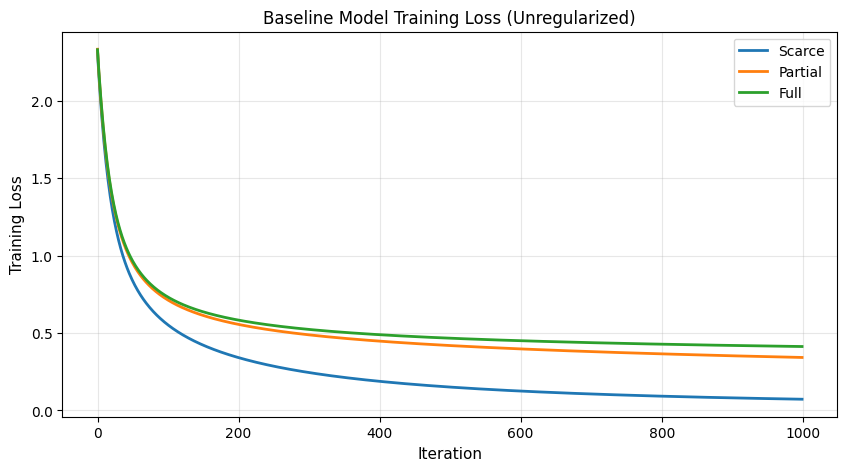

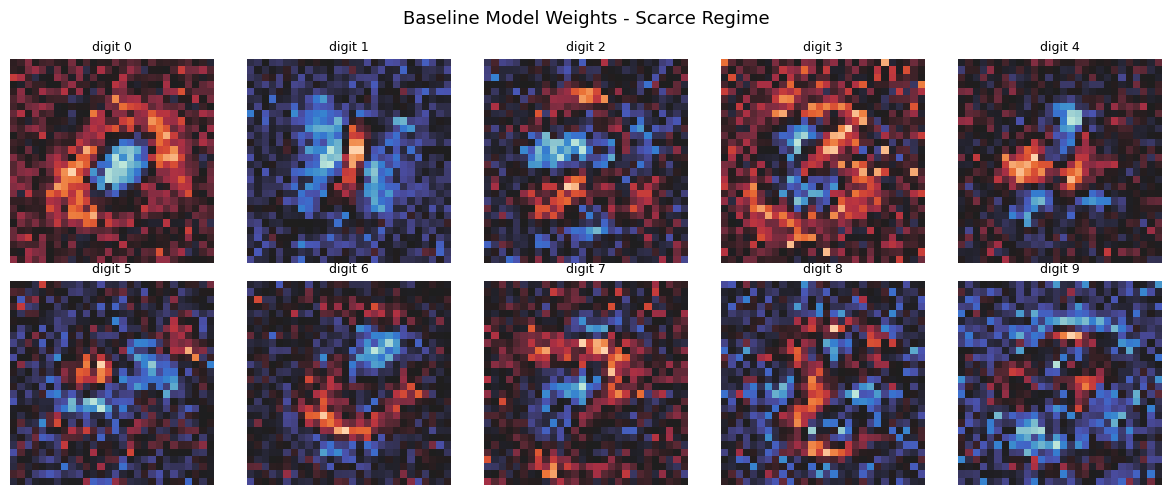

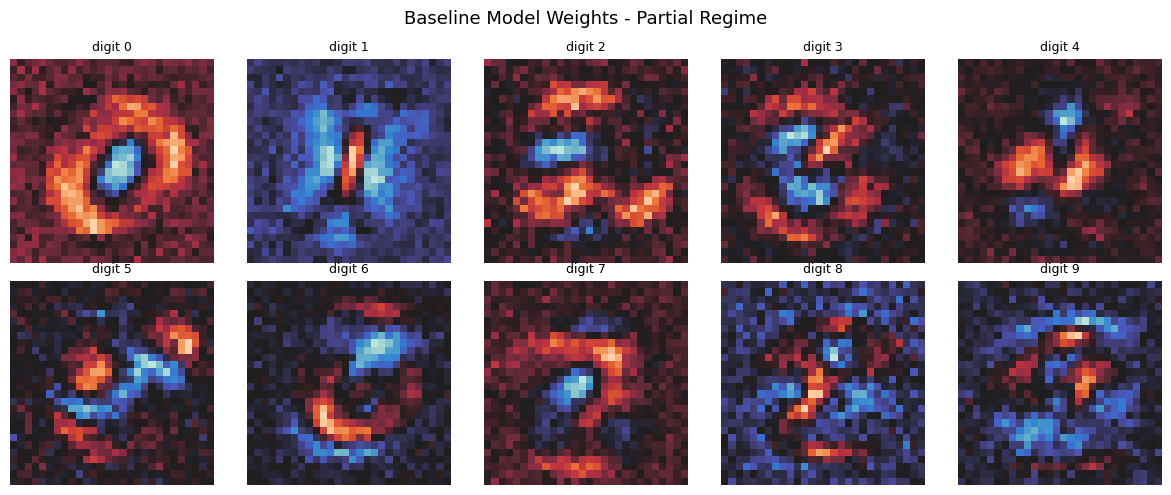

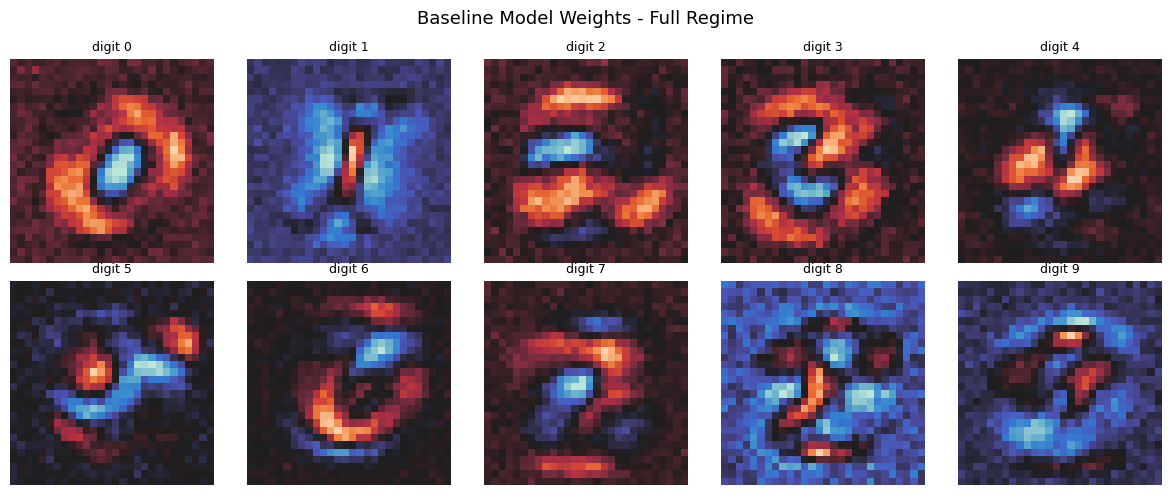

In [28]:
# Training baseline models (unregularized) for each data regime.
unreg_models = {}
unreg_losses = {}
n_iter = 1000

# Scarce
X_scarce = torch.FloatTensor(X_scarce_scaled[0])
y_scarce = torch.LongTensor(y_scarce)
model_scarce = LinearModel(n_features=X_scarce_scaled[0].shape[1], n_classes=10)
loss_scarce = train(model_scarce, X_scarce, y_scarce, n_iter, lr=0.1, l1=0.0, l2=0.0)
unreg_models["Scarce"] = model_scarce
unreg_losses["Scarce"] = loss_scarce

# Partial
print("Training baseline model on Partial regime...")
X_partial = torch.FloatTensor(X_partial_scaled[0])
y_partial = torch.LongTensor(y_partial)
model_partial = LinearModel(n_features=X_partial_scaled[0].shape[1], n_classes=10)
losses_partial = train(model_partial, X_partial, y_partial, n_iter, lr=0.1, l1=0.0, l2=0.0)
unreg_models["Partial"] = model_partial
unreg_losses["Partial"] = losses_partial

# Full
print("Training baseline model on Full regime...")
X_full = torch.FloatTensor(X_full_scaled[0])
y_full = torch.LongTensor(y_full)
model_full = LinearModel(n_features=X_full_scaled[0].shape[1], n_classes=10)
losses_full = train(model_full, X_full, y_full, n_iter, lr=0.1, l1=0.0, l2=0.0)
unreg_models["Full"] = model_full
unreg_losses["Full"] = losses_full


# Plot training losses for each regime
fig, ax = plt.subplots(figsize=(10, 5))
for regime_name, losses in unreg_losses.items():
    ax.plot(losses, label=regime_name, linewidth=2)
ax.set_xlabel("Iteration", fontsize=11)
ax.set_ylabel("Training Loss", fontsize=11)
ax.set_title("Baseline Model Training Loss (Unregularized)", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Visualize learned weights for each baseline model
for regime_name, model in unreg_models.items():
    weights = model.linear.weight.detach().numpy().astype(np.float32)
    plot_weights(weights, f"Baseline Model Weights - {regime_name} Regime")

> **Question 2.3**
>
> Inspect the weight images for each baseline model. How do you explain the
> weight values in the heatmap, and what patterns do they show?
>
> Compare between the model, how are they different?

R:
- Inspect the weight images for each baseline model. How do you explain the weight values in the heatmap, and what patterns do they show?

A cada valor de peso foi atribuída uma cor referente à escala adotada para o heatmap. Valores positivos estão representados com cores mais avermelhadas e valores negativos, com cores mais azuladas. Vemos que as partes que compõem os dígitos, em geral, estão mais avermelhadas, uma vez que contribuem para a sua caracterização e distinção, por apresentarem maior brilho nas imagens originais (valores brancos). Já as partes que não têm contribuição ou cuja contribuição é tangencial estão coloridas em azul ou mais próxima do preto.

(E quais padrões esses pesos mostram?)
Esses padrões específicos da distribuição de cores no heatmap corroboram com a hipótese de que o ruído não é dado de forma aleatória, e sim existe um padrão em que ele se dá, independente do modelo.

- Compare between the model, how are they different?

Podemos perceber que os dígitos estão mais destacados na cor vermelha no dataset Full, menos no Partial e menos ainda no Scarce. Isso indica que o modelo aprendeu melhor os padrões para o dataset Full, o que é esperado pois ele tem mais dados, enquanto que para o dataset Scarce, o modelo treinado capturou mais ruídos, ou seja, ele não sabe identificar corretamente a contribuição de determinado pixel para a construção de um dígito específico.

Esses resultados condizem com os gráficos plotados na primeira parte, nos quais era possível perceber que o dataset Scarce tinha ruído mais acentuado por dígito, em média, enquanto por outro lado, o Full contém, em média, menos corrupção por dígito, conforme vemos na imagem com heatmap, onde os números do Full são mais bem contornados com uma cor avermelhada.

---

## Part 3. Regularization

**(2.0 points)**

We now introduce regularization and sweep over $\lambda$ values for both L1 and L2 penalties.

Your **only decision criterion** in this part is cross-validation accuracy computed on the corrupted training data, exactly what you would have in a real scenario without access to an unlabeled clean test set.

For each configuration (data regime x reg type x $\lambda$), use K-fold cross-validation to estimate validation accuracy.
Then, for each regularizer, **select the best $\lambda$** by CV and train a final model on the full training set.
Store the final models, they will be evaluated after model selection is complete.

> **Decision task** Report, per regularizer and data regimes, which $\lambda$ you selected and why.
Inspect the weight images of your chosen models and describe what you observe.


In [31]:
# Implement K-fold cross-validation with correct pre-processing

from sklearn.model_selection import KFold

def kfold_cross_validation(
    regimes: list[tuple[str, NDArray[Any], NDArray[Any]]],
    list_lambdas: list[float],
    n_iter: int,
    lr: float = 0.1,
) -> dict:
    """
    Perform K-fold cross-validation across data regimes, regularization
    types (L1 and L2), and lambda values.

    Returns a dict mapping (regime, reg_type, lambda) -> mean val accuracy.
    """
    scores = {}
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    for regime_name, X_regime, y_regime in regimes:
        print(f"Cross-validating on {regime_name} data regime...")

        for tipo_reg in ("l1", "l2"):
            for l in list_lambdas:

                acuracias_dos_folds = []
                for train_idx, val_idx in kf.split(X_regime):

                    # Restart the model at each fold to avoid contamination
                    model = LinearModel(n_features=X_regime.shape[1], n_classes=10)

                    X_train_fold = X_regime[train_idx]
                    X_val_fold   = X_regime[val_idx]
                    y_train_fold = y_regime[train_idx]
                    y_val_fold   = y_regime[val_idx]
                    
                    # Convert to PyTorch tensors
                    X_train_fold = torch.FloatTensor(X_train_fold)
                    X_val_fold = torch.FloatTensor(X_val_fold)
                    y_train_fold = torch.LongTensor(y_train_fold)
                    y_val_fold = torch.LongTensor(y_val_fold)

                    # Use the current lambda in the correct argument
                    reg_l1 = l if tipo_reg == "l1" else 0.0
                    reg_l2 = l if tipo_reg == "l2" else 0.0

                    train(model, X_train_fold, y_train_fold, n_iter, lr, reg_l1, reg_l2)

                    # Forward pass on validation fold to get logits
                    with torch.no_grad():
                        logits_val = model(X_val_fold)

                    acuracias_dos_folds.append(accuracy(logits_val, y_val_fold))

                scores[(regime_name, tipo_reg, l)] = sum(acuracias_dos_folds) / len(acuracias_dos_folds)

    return scores

In [32]:
regimes = [
    ("Scarce",  X_scarce_scaled[0],  y_scarce),
    ("Partial", X_partial_scaled[0], y_partial),
    ("Full",    X_full_scaled[0],    y_full),
]

list_lambdas = [1.0, 0.1, 0.01, 0.001, 0.0001, 0.00001, 0.0]

scores = kfold_cross_validation(regimes, list_lambdas, n_iter=100, lr=0.1)

Cross-validating on Scarce data regime...
Cross-validating on Partial data regime...
Cross-validating on Full data regime...


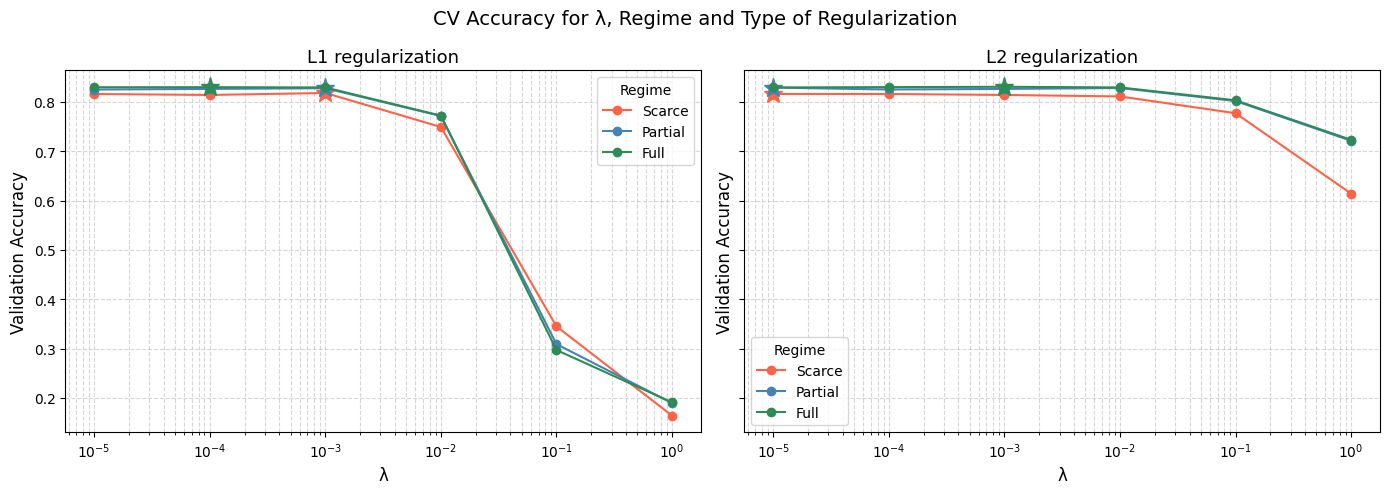

In [ ]:
# Function to visualize CV results clearly and informatively, highlighting the best lambda for each regime and regularization type
def plot_cv_scores(
    scores: dict,
    list_lambdas: list[float],
    regimes: list[str] = ["Scarce", "Partial", "Full"]
):
    # A figure with two subplots side by side: one for L1, another for L2
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    
    # Different colors for each data regime
    colors = {"Scarce": "tomato", "Partial": "steelblue", "Full": "seagreen"}

    for ax, tipo_reg in zip(axes, ["l1", "l2"]):
        for regime in regimes:
            # Extract accuracy for each lambda, in the correct order
            acuracias = [
                scores[(regime, tipo_reg, l)]
                for l in list_lambdas
            ]
            
            # Plot the line - log scale on X, so we pass lambdas directly
            ax.plot(
                list_lambdas,
                acuracias,
                marker="o",           # Marker at each point
                label=regime,
                color=colors[regime]
            )
            
            # Highlight the best lambda with a star
            best_idx = int(np.argmax(acuracias))
            ax.plot(
                list_lambdas[best_idx],
                acuracias[best_idx],
                marker="*",
                markersize=14,
                color=colors[regime]
            )

        ax.set_xscale("log")  # log scale on X axis
        ax.set_xlabel("λ", fontsize=12)
        ax.set_ylabel("Validation Accuracy", fontsize=12)
        ax.set_title(f"{tipo_reg.upper()} regularization", fontsize=13)
        ax.legend(title="Regime")
        ax.grid(True, which="both", linestyle="--", alpha=0.5)
        # "which=both" shows grid at major AND minor tick marks on log axis,
        # which helps a lot to read intermediate values

    plt.suptitle("CV Accuracy for λ, Regime and Type of Regularization", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_cv_scores(scores, list_lambdas[:-1])

In [ ]:
# Tabulate CV accuracy scores (L1 and L2) and print as plain tables
import pandas as pd

index_labels = [f"{lam:.0e}" if lam > 0 else "0" for lam in list_lambdas]
regimes = ["Scarce", "Partial", "Full"]

def build_cv_table(scores_dict, list_lams, reg_type):
    data = {regime: [scores_dict[(regime, reg_type, lam)] for lam in list_lams] for regime in regimes}
    df = pd.DataFrame(data, index=index_labels)
    df.index.name = "lambda"
    return df

print("CV accuracies (L1):")
df_l1 = build_cv_table(scores, list_lambdas, "l1")
print(df_l1.to_string(float_format=lambda x: f"{x:.4f}"))

print("\nCV accuracies (L2):")
df_l2 = build_cv_table(scores, list_lambdas, "l2")
print(df_l2.to_string(float_format=lambda x: f"{x:.4f}"))

CV accuracies (L1):
        Scarce  Partial   Full
lambda                        
1e+00   0.1640   0.1895 0.1909
1e-01   0.3450   0.3090 0.2971
1e-02   0.7490   0.7714 0.7721
1e-03   0.8180   0.8277 0.8293
1e-04   0.8140   0.8263 0.8298
1e-05   0.8160   0.8250 0.8296
0       0.8200   0.8253 0.8296

CV accuracies (L2):
        Scarce  Partial   Full
lambda                        
1e+00   0.6140   0.7212 0.7230
1e-01   0.7770   0.8017 0.8032
1e-02   0.8110   0.8281 0.8293
1e-03   0.8140   0.8262 0.8306
1e-04   0.8160   0.8251 0.8299
1e-05   0.8160   0.8289 0.8292
0       0.8180   0.8291 0.8304



REGIME: Scarce

Best λ for L1: 0.001 (CV accuracy: 0.7990)


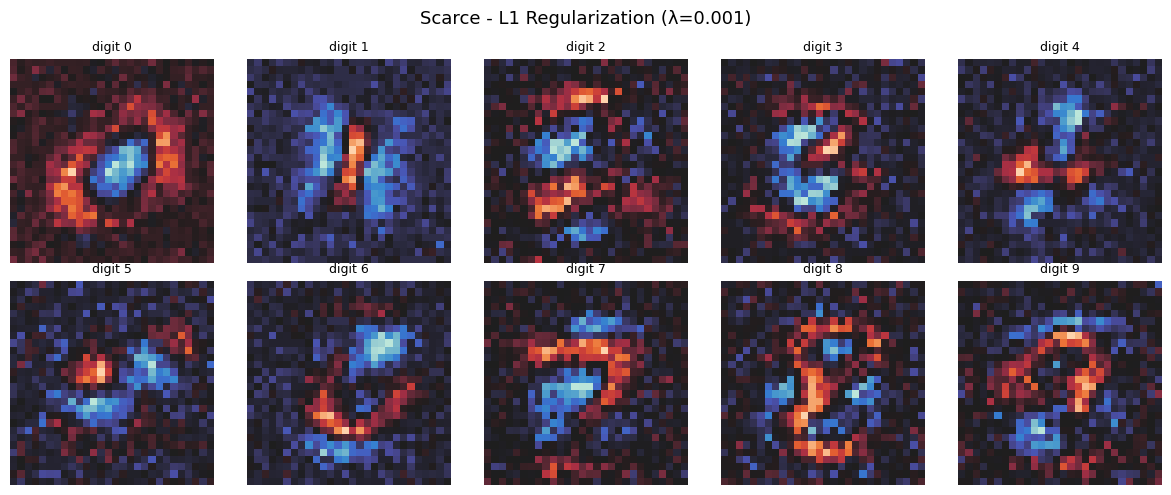


Best λ for L2: 0.01 (CV accuracy: 0.8040)


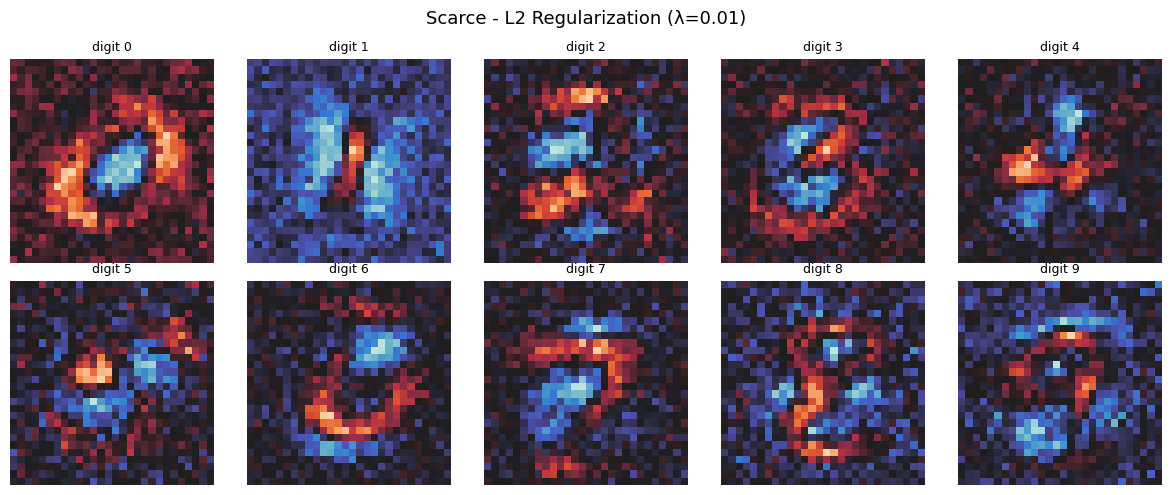


REGIME: Partial

Best λ for L1: 0.0001 (CV accuracy: 0.8303)


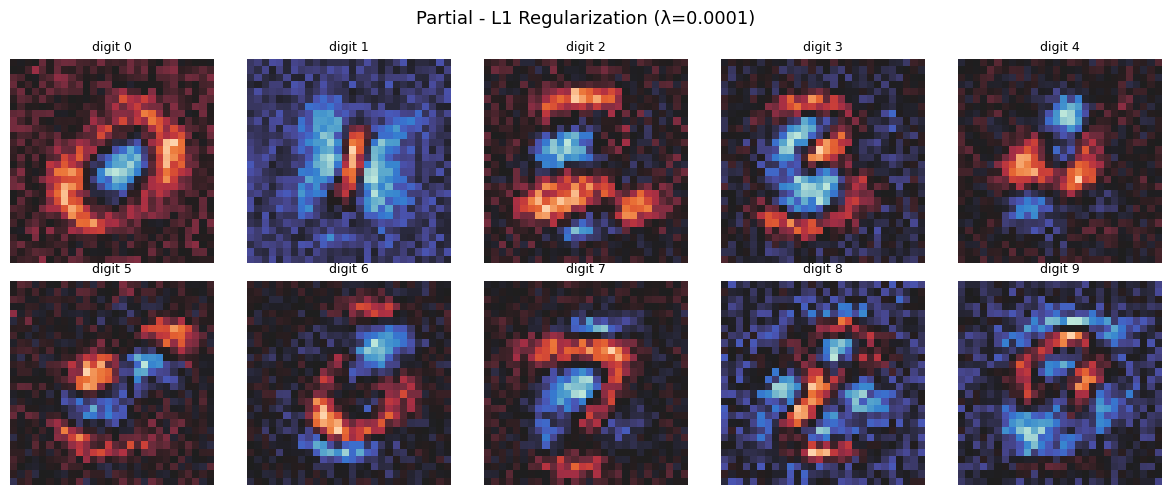


Best λ for L2: 1e-05 (CV accuracy: 0.8300)


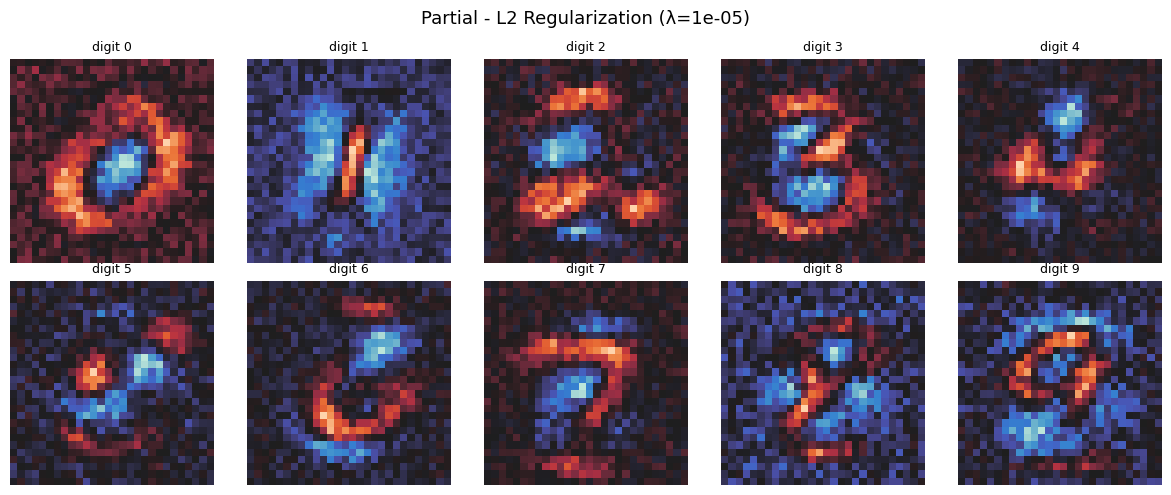


REGIME: Full

Best λ for L1: 1e-05 (CV accuracy: 0.8306)


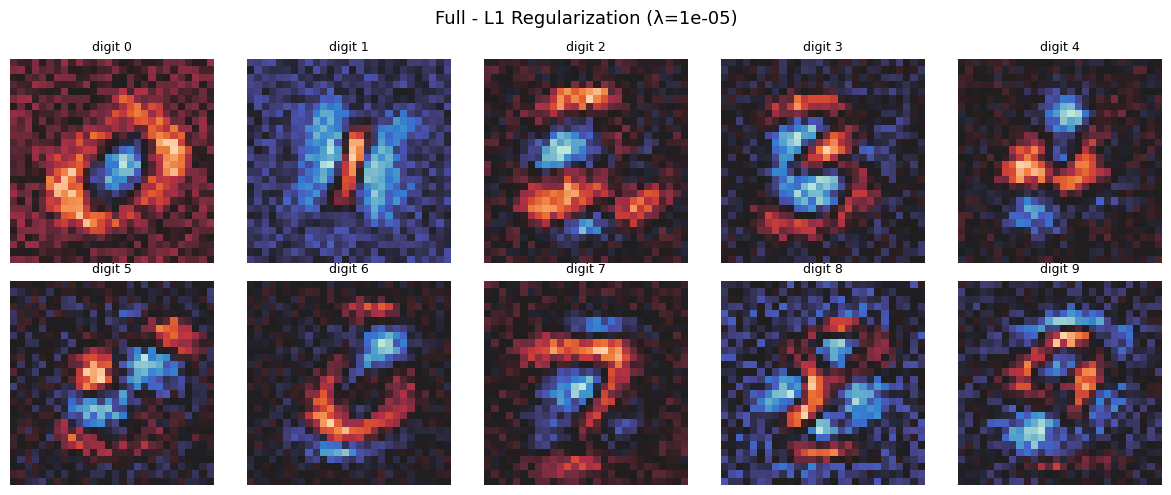


Best λ for L2: 1e-05 (CV accuracy: 0.8306)


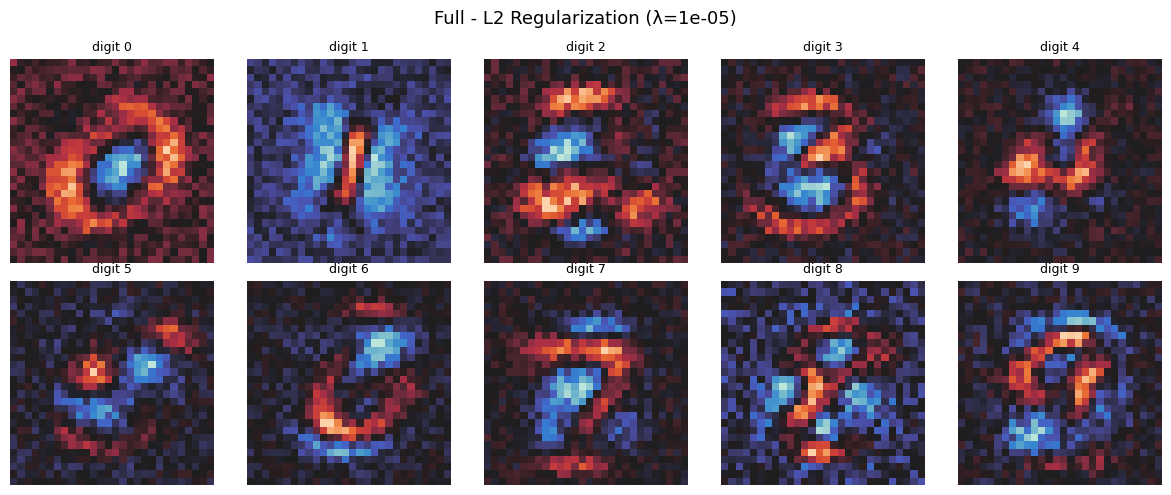

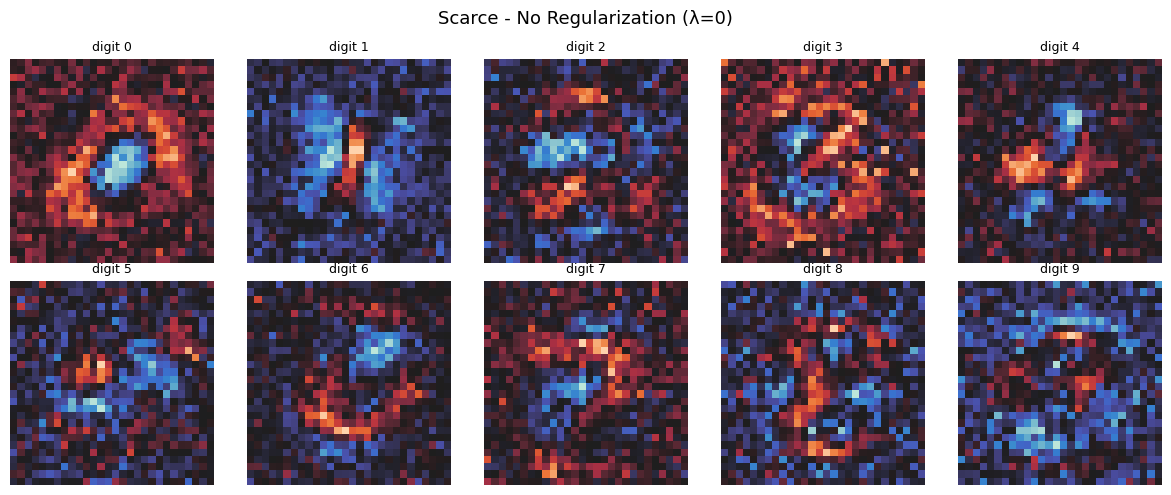

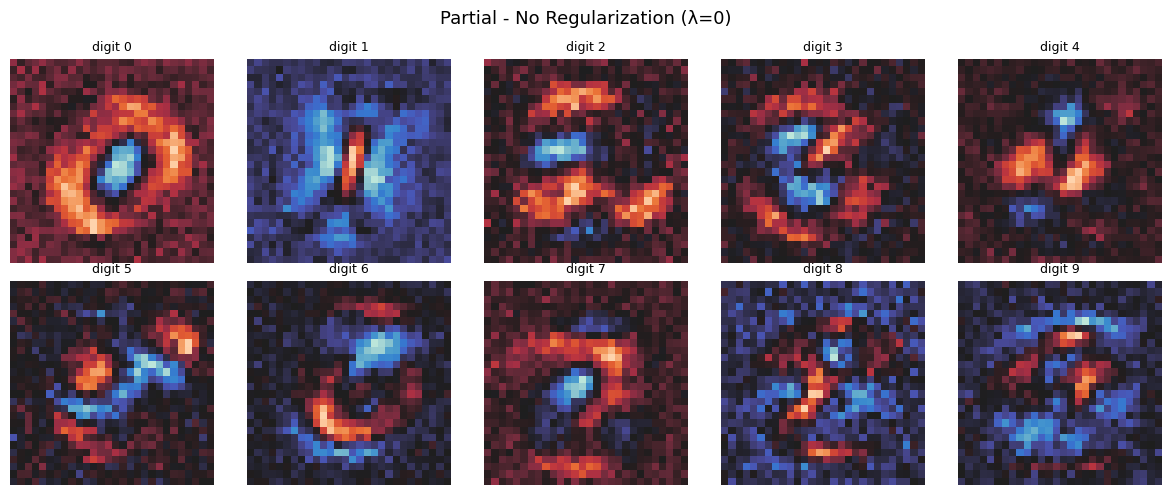

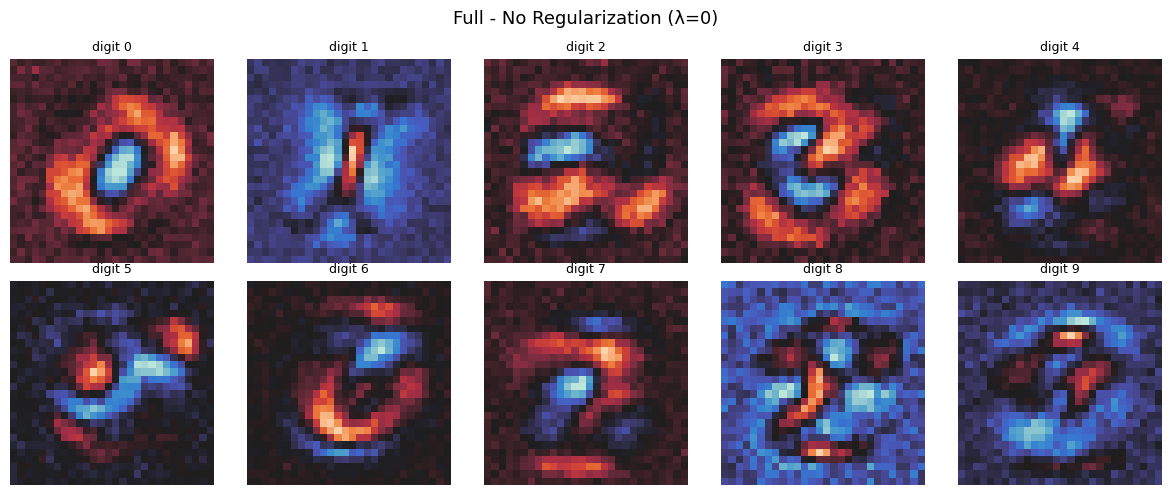

In [39]:
# Find best lambda for L1 and L2 in each regime, train final models, and visualize weights
best_models = {}

for regime_name, X_scaled, y in [
    ("Scarce", X_scarce_scaled[0], y_scarce),
    ("Partial", X_partial_scaled[0], y_partial),
    ("Full", X_full_scaled[0], y_full),
]:
    print(f"\n{'='*60}")
    print(f"REGIME: {regime_name}")
    print(f"{'='*60}")
    
    X_torch = torch.FloatTensor(X_scaled)
    y_torch = torch.LongTensor(y)
    
    for reg_type in ["l1", "l2"]:
        # Find best lambda for this regime and regularization type
        best_lambda = None
        best_accuracy = -1
        
        for lam in list_lambdas[:-1]:  # Exclude the unregularized case (lambda=0) from this search
            acc = scores[(regime_name, reg_type, lam)]
            if acc > best_accuracy:
                best_accuracy = acc
                best_lambda = lam
        
        print(f"\nBest λ for {reg_type.upper()}: {best_lambda} (CV accuracy: {best_accuracy:.4f})")
        
        # Train final model with best lambda on full training set
        model = LinearModel(n_features=X_scaled.shape[1], n_classes=10)
        
        if reg_type == "l1":
            train(model, X_torch, y_torch, n_iter=100, lr=0.1, l1=best_lambda, l2=0.0)
        else:
            train(model, X_torch, y_torch, n_iter=100, lr=0.1, l1=0.0, l2=best_lambda)
        
        best_models[(regime_name, reg_type)] = model
        
        # Visualize weights
        weights = model.linear.weight.detach().numpy().astype(np.float32)
        plot_weights(weights, f"{regime_name} - {reg_type.upper()} Regularization (λ={best_lambda})")


# Visualize weights for the models without regularization (lambda=0) for each regime, to compare with the best regularized models
for regime_name, model in unreg_models.items():
    weights = model.linear.weight.detach().numpy().astype(np.float32)
    plot_weights(weights, f"{regime_name} - No Regularization (λ=0)")

> **Question 4**
>
> (a) As $\lambda$ increases for L2 regularization, how does CV accuracy change on each data regime?
> Are there clear optima, or does accuracy plateau?
>
> (b) Compare the weight images of the CV-selected L2 model, the CV-selected L1 model, and the unregularized baseline. What differences do you observe in terms of structure and sparsity?
>
> (c) Connect the weight images to the corruption structure identified in Part 1. Does the CV-selected model appear to have suppressed the corruption pattern, amplified it, or is it ambiguous from weights alone?
>
> (d) **Predict**, based on what you see in the weights and CV curves, which of your three CV-selected models (none / L2 / L1) you expect will perform best on clean, uncorrupted images — and which worst. Justify your prediction before seeing any test results.


R:
(a) Conforme o $\lambda$ aumenta na regularização L2, a acurácia em todos os regimes de dados diminui. Observamos que para os conjuntos Partial e Full a diferença entre as performances é quase irrelevante, uma vez que as curvas estão sobrepostas. O comportamento de redução da acurácia teve a mesma tendência tanto para estes conjuntos, quanto para o Scarce, o qual apresentou valor menor em todo o intervalo de $\lambda$ avaliado, em especial para $\lambda=1.0$.
Notamos também que há um platô para o valor de acurácia em torno de 0.8 para todos os conjuntos, sendo obtido a partir de $\lambda=10^{-2}$.

(b) No Scarce, L1 e L2 produzem imagens visualmente similares — ambos limitados pela escassez de dados, em que digitos mais como 8 e 9 ainda aparecem confusos nos dois.
No Partial, a diferença começa a se manifestar: o L1 apresenta bordas mais definidas e fundo mais escuro, enquanto o L2 mostra uma névoa difusa de valores pequenos ao redor das formas.
No Full, o contraste é mais claro. O L1 concentra os pesos nos traços essenciais de cada dígito, zerando a maioria dos pixels irrelevantes. O L2 produz formas contínuas e suaves, sem zeros exatos — os pesos são pequenos em toda a imagem mas raramente nulos. Ambos são reconhecíveis, mas refletem naturezas distintas: L1 é cirúrgico 
e esparso, L2 é uniforme e difuso. 
Enquanto isso, o modelo sem regularização (λ=0) decora a corrupção do dataset especialmente no Scarce, onde as imagens mostram padrões aleatórios que não correspondem à estrutura dos dígitos. Isso corrobora com a hipótese inicial que esse modelo teria o overfitting mais acentuado ao ruído presente nos dados de treino. Com mais dados (Partial e Full), esse efeito diminui pois o modelo tem mais exemplos para aprender, dificultando decorar um padrão de ruido.

(c) A partir das imagens plotadas na Parte 1, percebemos que o padrão de corrupção é deixar os números ligeiramente borrados em todos os regimes de dados, e deixar as bordas menos pretas ou menos definidas em média, sendo o Scarce o regime com ruído mais acentuado, o Partial o regime com ruído mediano e o Full o com menos ruído. Observando as imagens do heatmap vermelho-azul, os modelos selecionados a partir da Cross-Validation claramente ainda concedem pesos positivos para ruídos, mas também concedem pesos azuis para pixels corretamente. Dessa forma, concluímos que é ambíguo dizer se o modelo selecionado amplifica ou suprime os ruídos identificados na parte 1.

(d) Baseado nas curvas de CV e no plot dos pesos, para o modelo Scarce, esperamos que o modelo sem regularização seja o que pior performará no test_corrupted, isso porque este conjunto provavelmente aprenderá o padrão do ruído e não a relação correta da distribuição. Em contra-ponto,para o test_clean esperamos que o regime Scarce com regularização Lasso performe melhor haja vista que a regularização vai atenuar o aprendizado de ruído, portanto levando a uma melhor acurácia em dados limpos . Já para o regime de dados Partial, esperamos que o modelo com regularização L1 performe melhor tanto no teste_corrupted quanto no teste_clean, visto que ele, por ter uma quantidade intermediária de dados, deve possuir um trade-off adequado entre aprender o ruído dos dados e o padrão da distribuição. Por fim, esperamos que o regime Full com regularização L2 performe melhor no test_clean que o baseline sem regularização. Essa previsão se deve em razão das imagens acima principalmente, onde é possível notar que a regularização consegue destacar mais a borda dos números. Além disso, como o dataset full consiste inteiramente de dados corruptos, então é esperado que ele se saia melhor quando testado para dados corruptos quando treinado sem regularização, e que não aprenda tão bem as referências para dados limpos,por isso, esperamos que a regularização atenue esse efeito e ele performe melhor nos dados limpos. Finalizando, portanto, o regime full sem regularização é previsto pelo grupo a performar pior que o L2 e L1 para o test_clean.


---

## Part 4. Test

**(2.0 points)**

Until now, all decisions, dataset size analysis, regularization selection, were made using only the corrupted training data and cross-validation.
**Now we use the test sets** to evaluate the models you selected.

In [33]:
# Load the test dataset and evaluate all the chosen models for each data regime
X_test = np.load("data/test/test_images.npy")
y_test = np.load("data/test/test_labels.npy")
X_clean = np.load("data/test/clean_images.npy")
y_clean = np.load("data/test/clean_labels.npy")

# Preprocess test data using the same scaling as training data (fit on training, transform on test)
X_test_scaled = X_test.reshape(X_test.shape[0], -1) / 255.0
X_clean_scaled = X_clean.reshape(X_clean.shape[0], -1) / 255.0

# Converte para tensores torch
X_test_torch = torch.FloatTensor(X_test_scaled)
y_test_torch  = torch.LongTensor(y_test)
X_clean_torch = torch.FloatTensor(X_clean_scaled)
y_clean_torch = torch.LongTensor(y_clean)

In [34]:
def train_all_lambdas(
    regimes: list[tuple[str, np.ndarray, np.ndarray]],
    list_lambdas: list[float],
    X_test_corrupted: torch.Tensor,
    y_test_corrupted: torch.Tensor,
    X_test_clean: torch.Tensor,
    y_test_clean: torch.Tensor,
    n_iter: int = 100,
    lr: float = 0.1,
 ) -> dict:
    """
    For each (regime, reg_type, lambda), train a model on the full training set
    and evaluate on both test sets.
    
    Returns dict: (regime, reg_type, lambda) -> (acc_corrupted, acc_clean)
    """
    tradeoff_results = {}

    for regime_name, X_scaled, y in regimes:
        X_torch = torch.FloatTensor(X_scaled)
        y_torch = torch.LongTensor(y)
        print(f"\nTraining all lambdas for regime: {regime_name}")

        for reg_type in ["l1", "l2"]:
            for lam in list_lambdas:
                model = LinearModel(n_features=X_scaled.shape[1], n_classes=10)

                if reg_type == "l1":
                    train(model, X_torch, y_torch, n_iter=n_iter, lr=lr, l1=lam, l2=0.0)
                else:
                    train(model, X_torch, y_torch, n_iter=n_iter, lr=lr, l1=0.0, l2=lam)

                with torch.no_grad():
                    acc_corr  = accuracy(model(X_test_corrupted), y_test_corrupted)
                    acc_clean = accuracy(model(X_test_clean),     y_test_clean)

                tradeoff_results[(regime_name, reg_type, lam)] = (acc_corr, acc_clean)
    return tradeoff_results

regimes = [
    ("Scarce",  X_scarce_scaled[0],  y_scarce),
    ("Partial", X_partial_scaled[0], y_partial),
    ("Full",    X_full_scaled[0],    y_full),
]

tradeoff_results = train_all_lambdas(
    regimes, list_lambdas,
    X_test_torch, y_test_torch,
    X_clean_torch, y_clean_torch,
)


Training all lambdas for regime: Scarce

Training all lambdas for regime: Partial

Training all lambdas for regime: Full


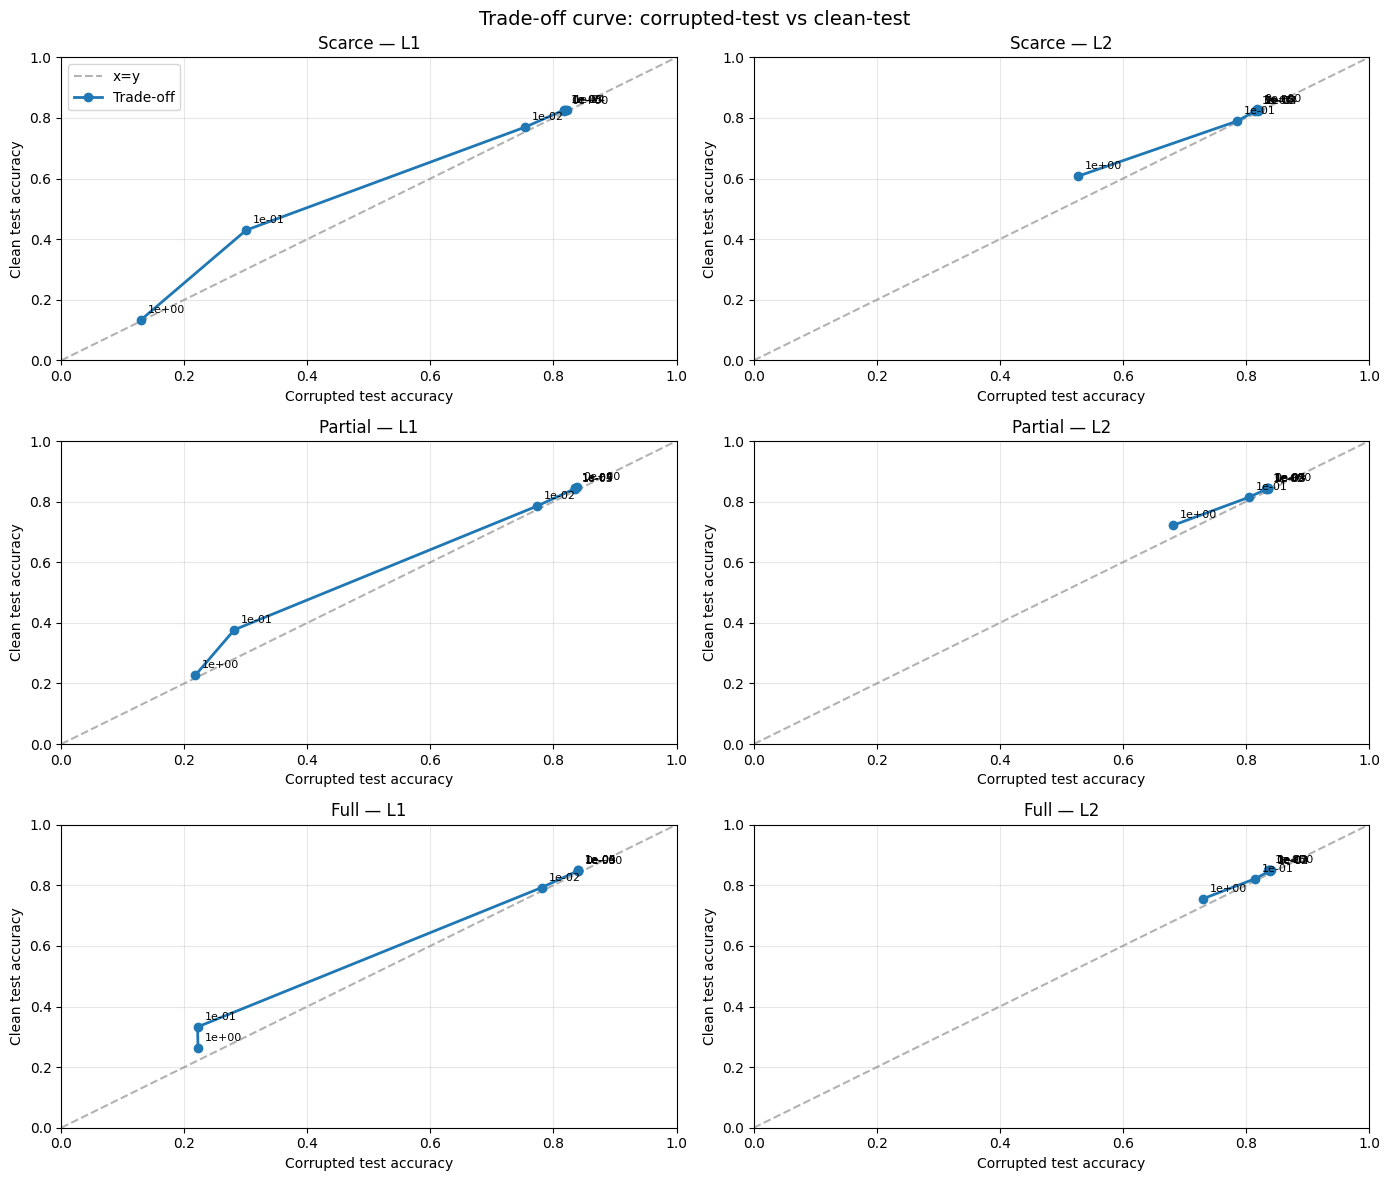

In [35]:
def plot_tradeoff_curve_1(
    tradeoff_results: dict,
    list_lambdas: list[float],
    regimes: list[str] = ["Scarce", "Partial", "Full"],
) -> None:
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))

    for row_idx, regime_name in enumerate(regimes):
        for col_idx, reg_type in enumerate(["l1", "l2"]):
            ax = axes[row_idx, col_idx]

            corrupted_accs = []
            clean_accs = []

            for lam in list_lambdas:
                acc_corr, acc_clean = tradeoff_results[(regime_name, reg_type, lam)]
                corrupted_accs.append(acc_corr)
                clean_accs.append(acc_clean)

            # Plot x=y line for reference
            ax.plot([0, 1], [0, 1], color="gray", linestyle="--", alpha=0.6, label="x=y")
            
            # Plot da curva de trade-off
            ax.plot(corrupted_accs, clean_accs, marker="o", linewidth=2, label="Trade-off")

            for idx, lam in enumerate(list_lambdas):
                ax.annotate(
                    f"{lam:.0e}",
                    (corrupted_accs[idx], clean_accs[idx]),
                    textcoords="offset points",
                    xytext=(5, 5),
                    fontsize=8,
                )

            ax.set_xlabel("Corrupted test accuracy")
            ax.set_ylabel("Clean test accuracy")
            ax.set_title(f"{regime_name} — {reg_type.upper()}")
            ax.grid(True, alpha=0.3)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            
            # Add legend for x=y curve
            if row_idx == 0 and col_idx == 0:
                ax.legend()

    plt.suptitle("Trade-off curve: corrupted-test vs clean-test", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_tradeoff_curve_1(tradeoff_results, list_lambdas)

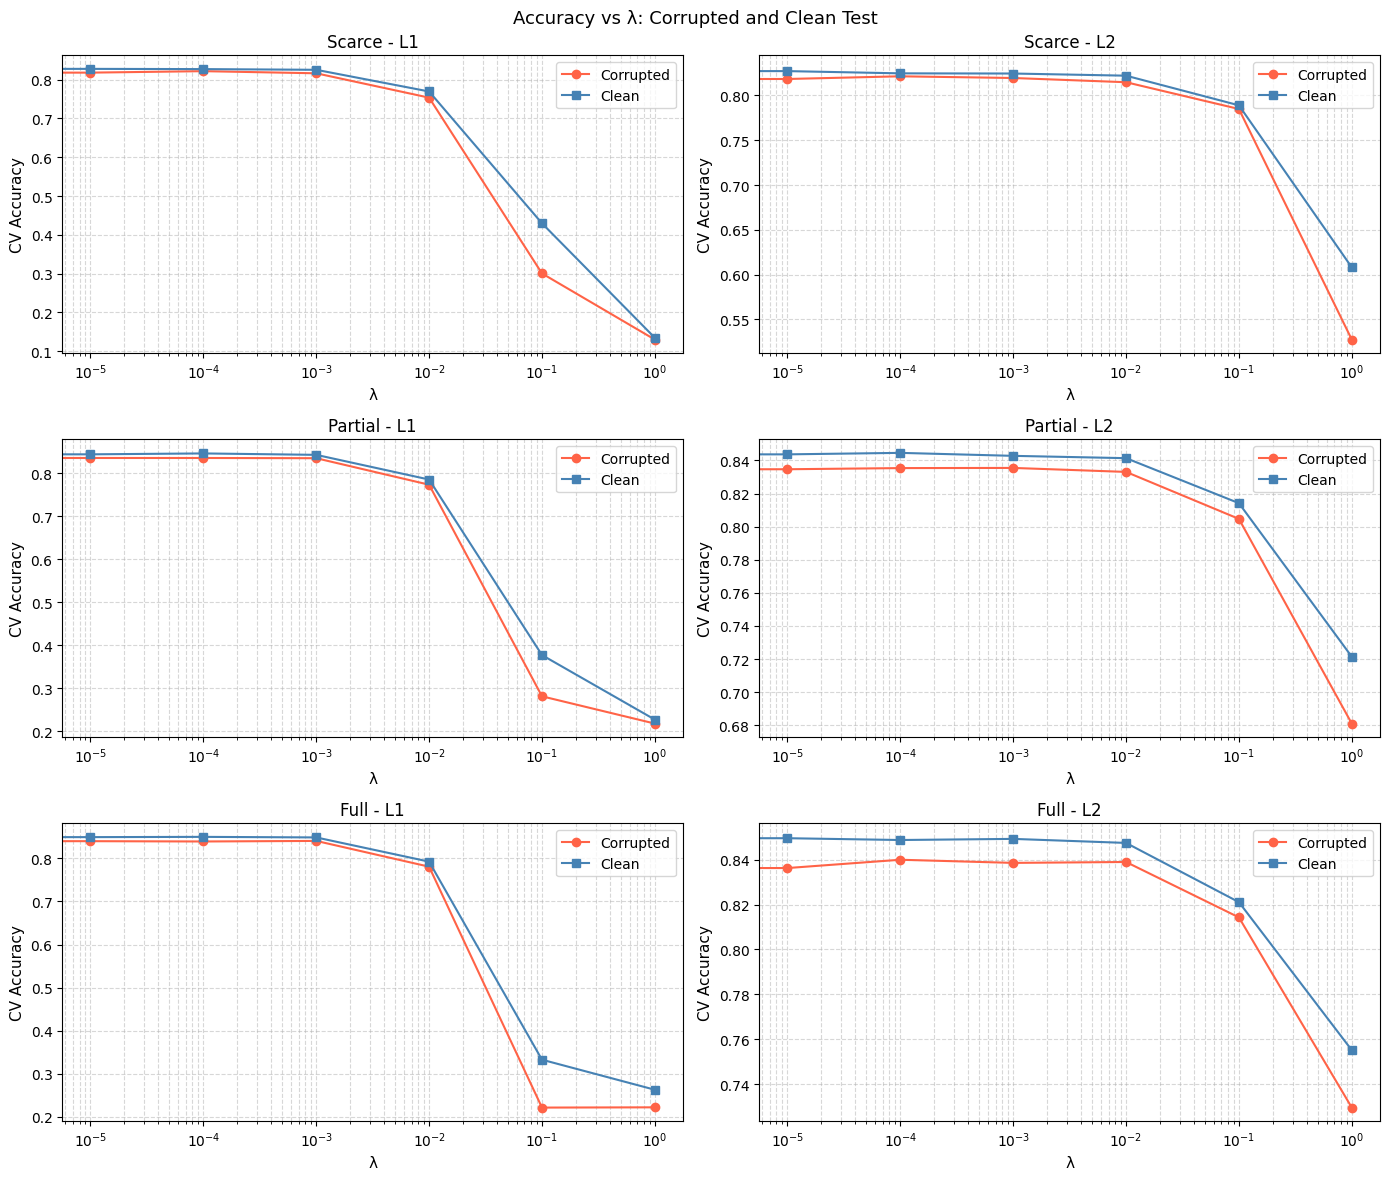

In [36]:
def plot_tradeoff_curve_2(
    tradeoff_results: dict,
    list_lambdas: list[float],
    regimes: list[str] = ["Scarce", "Partial", "Full"]
):
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))

    for row_idx, regime_name in enumerate(regimes):
        for col_idx, reg_type in enumerate(["l1", "l2"]):
            ax = axes[row_idx, col_idx]

            accs_corr  = []
            accs_clean = []

            for lam in list_lambdas:
                acc_corr, acc_clean = tradeoff_results[(regime_name, reg_type, lam)]
                accs_corr.append(acc_corr)
                accs_clean.append(acc_clean)

            ax.plot(list_lambdas, accs_corr,  marker="o", label="Corrupted", color="tomato")
            ax.plot(list_lambdas, accs_clean, marker="s", label="Clean",     color="steelblue")

            ax.set_xscale("log")
            ax.set_xlabel("λ", fontsize=11)
            ax.set_ylabel("CV Accuracy", fontsize=11)
            ax.set_title(f"{regime_name} - {reg_type.upper()}", fontsize=12)
            ax.legend()
            ax.grid(True, which="both", linestyle="--", alpha=0.5)

    plt.suptitle("Accuracy vs λ: Corrupted and Clean Test", fontsize=13)
    plt.tight_layout()
    plt.show()

plot_tradeoff_curve_2(tradeoff_results, list_lambdas)

In [37]:
# Tabulate accuracy scores (L1 and L2) and print as plain tables
import pandas as pd

index_labels = [f"{lam:.0e}" if lam > 0 else "0" for lam in list_lambdas]
regimes = ["Scarce", "Partial", "Full"]

def build_cv_table(tradeoff_results, list_lams, reg_type, data_type):
    data = {regime: [tradeoff_results[(regime, reg_type, lam)][data_type] for lam in list_lams] for regime in regimes}
    df = pd.DataFrame(data, index=index_labels)
    df.index.name = "lambda"
    return df

print("CV accuracies (L1)")
print("test_corrupted:")
df_l1 = build_cv_table(tradeoff_results, list_lambdas, "l1", 0)
print(df_l1.to_string(float_format=lambda x: f"{x:.4f}"))
print("\ntest_clean:")
df_l1 = build_cv_table(tradeoff_results, list_lambdas, "l1", 1)
print(df_l1.to_string(float_format=lambda x: f"{x:.4f}"))

print("\nCV accuracies (L2)")
print("test_corrupted:")
df_l2 = build_cv_table(tradeoff_results, list_lambdas, "l2", 0)
print(df_l2.to_string(float_format=lambda x: f"{x:.4f}"))
print("\ntest_clean:")
df_l2 = build_cv_table(tradeoff_results, list_lambdas, "l2", 1)
print(df_l2.to_string(float_format=lambda x: f"{x:.4f}"))

CV accuracies (L1)
test_corrupted:
        Scarce  Partial   Full
lambda                        
1e+00   0.1300   0.2179 0.2222
1e-01   0.3005   0.2813 0.2216
1e-02   0.7536   0.7730 0.7806
1e-03   0.8164   0.8346 0.8404
1e-04   0.8219   0.8351 0.8391
1e-05   0.8181   0.8351 0.8398
0       0.8169   0.8379 0.8397

test_clean:
        Scarce  Partial   Full
lambda                        
1e+00   0.1346   0.2271 0.2630
1e-01   0.4297   0.3771 0.3327
1e-02   0.7695   0.7850 0.7923
1e-03   0.8254   0.8424 0.8485
1e-04   0.8272   0.8457 0.8498
1e-05   0.8278   0.8436 0.8492
0       0.8232   0.8470 0.8478

CV accuracies (L2)
test_corrupted:
        Scarce  Partial   Full
lambda                        
1e+00   0.5275   0.6810 0.7295
1e-01   0.7849   0.8047 0.8143
1e-02   0.8148   0.8331 0.8390
1e-03   0.8195   0.8355 0.8386
1e-04   0.8214   0.8354 0.8400
1e-05   0.8184   0.8347 0.8363
0       0.8185   0.8353 0.8381

test_clean:
        Scarce  Partial   Full
lambda                        
1e+0

Scarce - Best λ for L1: 0.001 (CV accuracy: 0.8180)
Scarce - Best λ for L2: 1e-05 (CV accuracy: 0.8160)
Partial - Best λ for L1: 0.001 (CV accuracy: 0.8277)
Partial - Best λ for L2: 1e-05 (CV accuracy: 0.8289)
Full - Best λ for L1: 0.0001 (CV accuracy: 0.8298)
Full - Best λ for L2: 0.001 (CV accuracy: 0.8306)

Training final models and evaluating on test datasets...

Scarce Regime:
  Baseline - Corrupted: 0.8243, Clean: 0.8376
  L1 (λ=0.001) - Corrupted: 0.8221, Clean: 0.8383
  L2 (λ=1e-05) - Corrupted: 0.8216, Clean: 0.8344

Partial Regime:
  Baseline - Corrupted: 0.8398, Clean: 0.8508
  L1 (λ=0.001) - Corrupted: 0.8385, Clean: 0.8501
  L2 (λ=1e-05) - Corrupted: 0.8398, Clean: 0.8506

Full Regime:
  Baseline - Corrupted: 0.8418, Clean: 0.8510
  L1 (λ=0.0001) - Corrupted: 0.8372, Clean: 0.8480
  L2 (λ=0.001) - Corrupted: 0.8409, Clean: 0.8527


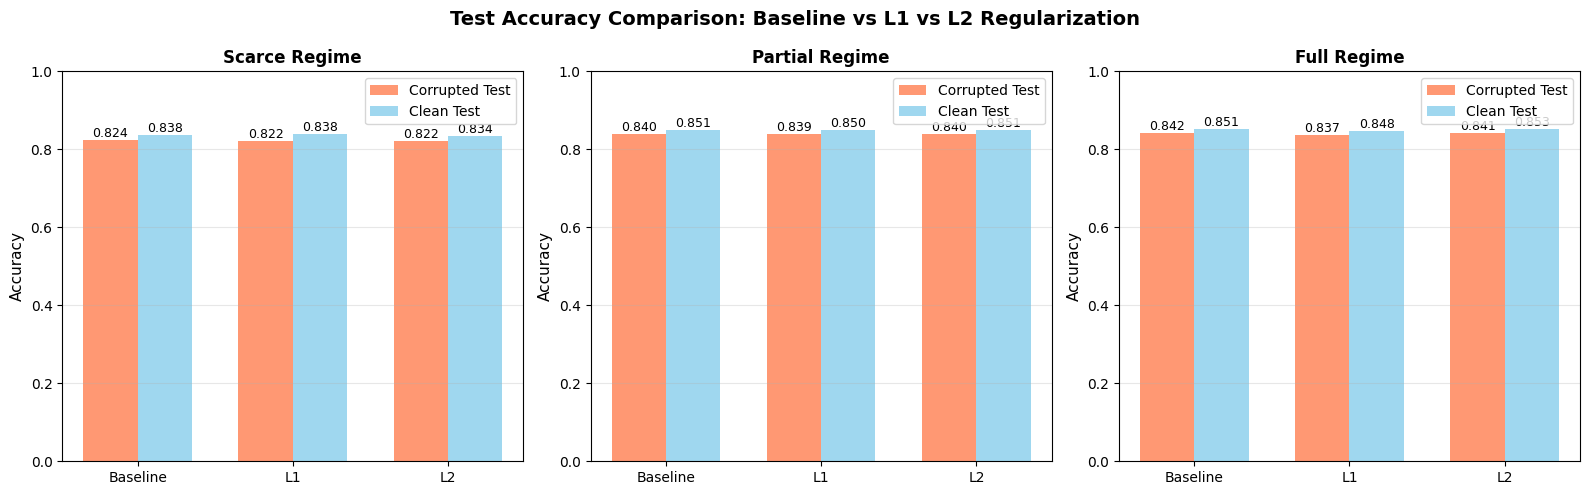

In [ ]:
# Train final models with best lambdas and plot accuracy comparison on test datasets

# First, find the best lambdas for L1 and L2 in each regime
best_lambdas = {}

for regime_name in ["Scarce", "Partial", "Full"]:
    best_lambdas[regime_name] = {"l1": None, "l2": None}
    
    for reg_type in ["l1", "l2"]:
        best_lambda = None
        best_accuracy = -1
        
        for lam in list_lambdas[:-1]:  # Exclude lambda=0
            acc = scores[(regime_name, reg_type, lam)]
            if acc > best_accuracy:
                best_accuracy = acc
                best_lambda = lam
        
        best_lambdas[regime_name][reg_type] = best_lambda
        print(f"{regime_name} - Best λ for {reg_type.upper()}: {best_lambda} (CV accuracy: {best_accuracy:.4f})")

print("\n" + "="*70)
print("Training final models and evaluating on test datasets...")
print("="*70)

# Train final models on full training set and evaluate on test data
results = {}

for regime_name, X_scaled, y in [
    ("Scarce", X_scarce_scaled[0], y_scarce),
    ("Partial", X_partial_scaled[0], y_partial),
    ("Full", X_full_scaled[0], y_full),
]:
    X_torch = torch.FloatTensor(X_scaled)
    y_torch = torch.LongTensor(y)
    
    results[regime_name] = {}
    
    # Model 1: Baseline (no regularization)
    model_baseline = LinearModel(n_features=X_scaled.shape[1], n_classes=10)
    train(model_baseline, X_torch, y_torch, n_iter=100, lr=0.1, l1=0.0, l2=0.0)
    
    with torch.no_grad():
        acc_baseline_corrupted = accuracy(model_baseline(X_test_torch), y_test_torch)
        acc_baseline_clean = accuracy(model_baseline(X_clean_torch), y_clean_torch)
    
    results[regime_name]["Baseline"] = (acc_baseline_corrupted, acc_baseline_clean)
    
    # Model 2: Best L1
    best_l1 = best_lambdas[regime_name]["l1"]
    model_l1 = LinearModel(n_features=X_scaled.shape[1], n_classes=10)
    train(model_l1, X_torch, y_torch, n_iter=100, lr=0.1, l1=best_l1, l2=0.0)
    
    with torch.no_grad():
        acc_l1_corrupted = accuracy(model_l1(X_test_torch), y_test_torch)
        acc_l1_clean = accuracy(model_l1(X_clean_torch), y_clean_torch)
    
    results[regime_name]["L1"] = (acc_l1_corrupted, acc_l1_clean)
    
    # Model 3: Best L2
    best_l2 = best_lambdas[regime_name]["l2"]
    model_l2 = LinearModel(n_features=X_scaled.shape[1], n_classes=10)
    train(model_l2, X_torch, y_torch, n_iter=100, lr=0.1, l1=0.0, l2=best_l2)
    
    with torch.no_grad():
        acc_l2_corrupted = accuracy(model_l2(X_test_torch), y_test_torch)
        acc_l2_clean = accuracy(model_l2(X_clean_torch), y_clean_torch)
    
    results[regime_name]["L2"] = (acc_l2_corrupted, acc_l2_clean)
    
    print(f"\n{regime_name} Regime:")
    print(f"  Baseline - Corrupted: {acc_baseline_corrupted:.4f}, Clean: {acc_baseline_clean:.4f}")
    print(f"  L1 (λ={best_l1}) - Corrupted: {acc_l1_corrupted:.4f}, Clean: {acc_l1_clean:.4f}")
    print(f"  L2 (λ={best_l2}) - Corrupted: {acc_l2_corrupted:.4f}, Clean: {acc_l2_clean:.4f}")

# Plot accuracy comparison for each regime
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_list = ["Baseline", "L1", "L2"]
x = np.arange(len(models_list))
width = 0.35

for idx, (regime_name, ax) in enumerate(zip(["Scarce", "Partial", "Full"], axes)):
    corrupted_accs = [results[regime_name][model][0] for model in models_list]
    clean_accs = [results[regime_name][model][1] for model in models_list]
    
    bars1 = ax.bar(x - width/2, corrupted_accs, width, label="Corrupted Test", color="coral", alpha=0.8)
    bars2 = ax.bar(x + width/2, clean_accs, width, label="Clean Test", color="skyblue", alpha=0.8)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=9)
    
    ax.set_ylabel("Accuracy", fontsize=11)
    ax.set_title(f"{regime_name} Regime", fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(models_list)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle("Test Accuracy Comparison: Baseline vs L1 vs L2 Regularization", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

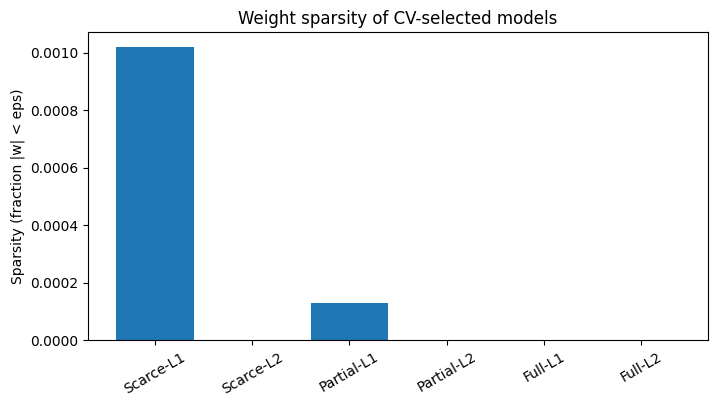

Scarce-L1: 0.0010
Scarce-L2: 0.0000
Partial-L1: 0.0001
Partial-L2: 0.0000
Full-L1: 0.0000
Full-L2: 0.0000


In [40]:
def model_sparsity(model, eps):
    W = model.linear.weight.detach().cpu().numpy()
    return float(np.mean(np.abs(W) < eps))

order = [
    ("Scarce", "l1"),
    ("Scarce", "l2"),
    ("Partial", "l1"),
    ("Partial", "l2"),
    ("Full", "l1"),
    ("Full", "l2"),
]

labels, values = [], []
for key in order:
    if key in best_models:
        labels.append(f"{key[0]}-{key[1].upper()}")
        values.append(model_sparsity(best_models[key], eps=1e-6))

plt.figure(figsize=(8, 4))
plt.bar(labels, values)
plt.ylabel("Sparsity (fraction |w| < eps)")
plt.title("Weight sparsity of CV-selected models")
plt.xticks(rotation=30)
plt.show()

for label, value in zip(labels, values):
    print(f"{label}: {value:.4f}")

> **Question 5**
>
> (a) Describe the shape of the trade-off curve (corrupted-test vs. clean-test). Is there a region where increasing regularization simultaneously improves both accuracies? Is there a region of genuine trade-off?
>
> (b) The CV-selected models are marked on the plot. Where do they fall relative to the trade-off frontier? What does this tell you about using cross-validation as a model selection criterion when training and deployment distributions differ?
>
> (c) Revisit your prediction from Question 4(d). Was it correct? If not, what did the weight images fail to reveal that the test results exposed?
>
> (d) Connect the sparsity plot to the OOD results. Why might L1 regularization behave differently from L2 when evaluated on clean images?
>
> (e) In a real deployment scenario, the clean test set would not be available during model selection. Given only corrupted validation data, what practical strategies could a practitioner use to make a better model selection decision than simply maximizing CV accuracy?


R:
(a) Nos gráficos da regularização L1, é possível observar que as curvas se acompanham para lambdas pequenos, em especial para valores de $\lambda = 0$ até $\lambda = 10^{-2}$. Isso indica que uma regularização fraca não afeta significativamente nenhum dos dois conjuntos, apenas nota-se a manutenção da acurácia em válores iguais ou superiores a 0.8. Para valores maiores de $\lambda$, ou seja, $10^{-2} \le \lambda \le 1$, notamos um decaimento acentuado da acurácia, tanto no test_corrupted, quanto no test_clean, sendo que a queda de performance de test_corrupted fica um pouco mais pronunciada. Apesar disso, a diferença entre as duas curvas para o regime Full é bastante substancial, sendo um pouco mais significativa para o regime Partial e para o Scarce.

Já nos gráficos da regularização L2, observamos um trade-off um pouco maior entre os curvas, embora este ainda seja pequeno. Novamente, a performance no test_clean é maior que a de test_corrupted em todos os subconjuntos, porém com um gap maior entre os valores de acurácia quando comparado à regularização L1. Vemos também que novamente as curvas de ambos conjuntos de teste se acompanham em todos os gráficos desta forma de regularização, mantendo o padrão de valores de acurácia em torno de 0.8 para $\lambda$ s menores e decaindo intensamente a partir de $\lambda=10^{-2}.$

Sendo assim, tanto a análise anterior, quanto o plot de acurácia de test_clean vs. test_corrupted ilustram que aumentar a regularização (ou seja, aumentar os valores de $\lambda$, deixando o modelo mais rígido) não gerou uma região de aumento nas duas acurácias. Na verdade, obervamos o oposto: ou as acurácias se mantiveram em um platô (para $\lambda$ s pequenos) ou diminuíram drasticamente (para para $\lambda$ s mais próximos de 1). Isso fica evidente quando vemos que os pontos que compõem as cuvas de trade-off no gráfico de clean_test vs. corrupted_test estão próximos à reta x=y, indicando ser a difrença de performance tangencial para os diferentes test sets, independentemente do modelo. Assim, os plots nos mostraram não ter havido uma região de trade-off genuíno entre as curvas de teste.

(b) Os modelos selecionados pelo CV caem na região de platô da curva de trade-off, onde tanto a acurácia no teste corrompido quanto no limpo são simultaneamente altas (~0.82-0.83). Isso ocorre porque o CV selecionou lambdas pequenos ($10^{-4}$ a $10^{-3}$, ou até mesmo 0), que estão na região onde as duas curvas ainda não divergiram. Isso revela uma limitação importante do CV como critério de seleção quando as distribuições de treino e deploy diferem: o CV otimiza exclusivamente para a distribuição de treino (corrompida). Nesse caso, o resultado foi favorável porque o $\lambda$ ótimo para o corrupted coincidiu com uma região boa para o clean. Porém, se a divergência entre as distribuições fosse maior, o CV poderia selecionar um modelo que performa bem no test_corrupted mas mal no test_clean, sem que tenhamos como detectar isso sem acesso aos dados de deploy, que era nossa intuição inicial sobre como os modelos iriam performar.

(c) Em relação ao regime Scarce, a hipótese estava correta, pois vemos que o model sem regularização de fato foi o que melhor performou no test_corrupted, além disso, de fato o L1 performa melhor no test_clean. Já para o regime Partial, previmos que o modelo com regularização L1 performaria melhor no test_corrupted e clean. Esta previsão está errada conforme mostra os resultados acima. Por último, para o regime Full, a hipótese estava correta ao prever que a regularização L2 performaria melhor no test_clean. Finalizando, é importante falar que a acurácia entre  entre  modelos (baseline, L1 e L2) dento de um mesmo  regime (Scarce, Partial e Full) está muito próxima, as vezes com diferença apenas na quarta casa decimal. Esse resultado foi inesperado, pois vendo apenas os gráficos acima de heatmap os modelos indicavam que teriam resultados mais distintos.

(d) Vemos o plot de esparsidade no gráfico "Weight sparsity of CV-selected models", em que se definiu um valor muito baixo como threshold (1e-6) para filtrar os valores de pesos próximos à zero e calcular a fração destes em relação à quantidade total de pesos. O resultado obtido condiz com a expectativa para as regularizações L1 e L2, uma vez que a primeira tende a zerar ou atribuir valor muito baixos a pixels não informativos e a segunda distribui peso por todos os pixels, sem zerá-los. Por isso, esperamos alta esparsidade de modelos que usam L1 e baixa esparsidade dos modelos que usam L2. Vemos que nos OOD results, ou seja, nos resultados para o test_clean (aqueles que não estavam no conjunto de treino), o modelo menos esparso (L2) foi o que, em geral, performou melhor para o test_clean, independentemente do conjunto usado no treino. Porém, notamos que as diferenças são de no máximo 0.1 pontos de acurácia entre os modelos que usam L1 ou L2.

Tendo isso em mente, sabemos que L1 produz pesos mais esparsos, o que reduz a dependência de padrões de ruído da corrupção. E, de modo geral, isso pode reduzir a lacuna entre o treino com dados ruidosos e teste com dados sem qualquer aplicação de ruído. Já L2 mantém muitos pesos pequenos distribuídos, o que pode ainda propagar a influência do ruído. Por esses motivos, L1 e L2 podem ter comportamento diferentes em dados OOD, mesmo com performance parecida no test_corrupted. No entanto, ressaltamos que, embora este seja o padrão teórico e usual, no nosso caso, o modelo L2 foi o que performou melhor para a maioria dos testes, mesmo que a diferença de acurácia tenha sido tangencial.

(e) Algumas estratégias gerais alternativas à melhor CV Accuracy para selecionar o melhor modelo são: aplicar técnicas para remover parcialmente o ruído das imagens do conjunto de treino ou atenuá-lo, de modo a torná-lo mais próximo ao de teste; usar a mesma técnica descrita anteriormente, mas apenas aplicada ao split de validação, de modo a simular o deploy (criar um proxy); adicionar outros tipos de ruído aos dados, de intensidades e tipos diferentes; escolher um modelo com melhor trade-off entre acurácia e sensibilidade à mudança na distrbuição de dados (modelo não overfittado aos dados de treino).

Neste caso, como temos apenas dados de validação com ruído, ao invés de selecionar o $\lambda$ que maximiza a CV, poderíamos escolher aquele que mantém a performance mais estável quando se altera a quantidade de dados no dataset ou até mesmo o tipo ou nível de ruído aplicado às imagens. A ideia é que isto reduza a perda de performance no test set clean, mesmo sem usá-lo no treinamento.

---

## Summary

Complete the table below with results from your experiments. Use the best model according to each criterion.

| Model                              | CV Accuracy | Test Acc (corrupted) | Test Acc (clean) |  Gap  |
|------------------------------------|-------------|----------------------|------------------|-------|
| No regularization (baseline)       |   0.8304    |        0.8418        |     0.8510       |-0.0092|
| Best CV, L2                        |   0.8304    |        0.8409        |     0.8527       |-0.0118|
| Best CV, L1                        |   0.8296    |        0.8385        |     0.8501       |-0,0116|
| Smallest in/out gap, L2            |   0.8160    |        0.8216        |     0.8344       |-0.0128|
| Smallest in/out gap, L1            |   0.8180    |        0.8221        |     0.8383       |-0.0162|

*Gap = Test Acc (corrupted) - Test Acc (clean).*

---

## Assignment Submission

This notebook must be filled with your solution and submitted on the Assignment's entry at our Google Classroom page.

Before submitting, verify that:
- The notebook runs end-to-end without errors (use **Run All** after restarting the kernel).
- All plots are rendered in the output.
- All written answers are filled in.
- The summary table is completed.
- AI usage declaration and prompts are included if applicable.

**Important: Only one member of the group should submit.**

### Policy for late submissions

You are NOT encouraged to submit after the deadline; however, in this case the following penalties apply:

- 25% deduction for 1-day late submission.
- 50% deduction for 2-day late submission.
- 75% deduction for 3-day late submission.